<a href="https://colab.research.google.com/github/kaushik989/NeuroCore-AI/blob/main/Soil_(pH)_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TEAM MEMBERS

# Uploading dataset

In [1]:
!gdown --id 1_MQ-cJU0sZr7hyg4UBCdO3TqtppUIuFK

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1_MQ-cJU0sZr7hyg4UBCdO3TqtppUIuFK
To: /content/SOIL DATA GR.csv
100% 61.6k/61.6k [00:00<00:00, 67.4MB/s]


# Import necessary libary

In [2]:
import pandas as pd
from scipy import stats
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

# Load Dataset and read

In [3]:
# Load dataset
df = pd.read_csv('/content/SOIL DATA GR.csv')

Overview of the data

In [4]:
# Check the first few rows
print(df.head())

   ID  Sand %  Clay %  Silt %     pH  EC mS/cm    O.M. %  CACO3 %  N_NO3 ppm  \
0   1    42.0    38.0    20.0  5.162     0.274  3.783414     0.00  14.462366   
1   2    54.0    26.0    20.0  6.071     0.355  1.451688     0.00  14.587814   
2   3    28.0    36.0    36.0  6.921     0.675  1.767599     0.40  14.910394   
3   4    58.0    20.0    22.0  7.704     0.355  0.718322     6.80   4.211470   
4   5    33.2    41.2    25.6  7.609     0.392  0.996625     4.39   6.111111   

       P ppm  K ppm   Mg ppm  Fe ppm  Zn ppm  Mn ppm  Cu ppm  B ppm  
0  18.608840     147    1115   91.32   0.894   27.06   1.768   0.40  
1  32.742137     180    1055   60.04   3.660   17.58   1.684   0.41  
2  19.024525     183    1215   61.24   3.060   18.00   1.840   0.46  
3   6.276846     116     327   19.54   1.640    5.04   0.844   0.50  
4   6.553970     228     939   25.84   0.180    7.16   1.216   0.40  


In [5]:
# Summary of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         781 non-null    int64  
 1   Sand %     781 non-null    float64
 2   Clay %     781 non-null    float64
 3   Silt %     781 non-null    float64
 4   pH         781 non-null    float64
 5   EC mS/cm   781 non-null    float64
 6   O.M. %     781 non-null    float64
 7   CACO3 %    781 non-null    float64
 8   N_NO3 ppm  781 non-null    float64
 9   P ppm      781 non-null    float64
 10  K ppm      781 non-null    int64  
 11  Mg ppm     781 non-null    int64  
 12  Fe ppm     781 non-null    float64
 13  Zn ppm     781 non-null    float64
 14  Mn ppm     780 non-null    float64
 15  Cu ppm     781 non-null    float64
 16  B ppm      781 non-null    float64
dtypes: float64(14), int64(3)
memory usage: 103.9 KB
None


In [6]:
# Statistical summary of the data
print(df.describe())

               ID      Sand %      Clay %      Silt %          pH    EC mS/cm  \
count  781.000000  781.000000  781.000000  781.000000  781.000000  781.000000   
mean   391.000000   31.529321   34.997183   33.473496    7.133668    0.452793   
std    225.599572   10.978371   11.252452    8.384172    0.897823    0.304841   
min      1.000000   10.000000    6.000000   14.000000    4.490000    0.134000   
25%    196.000000   24.000000   28.000000   28.000000    6.660000    0.338000   
50%    391.000000   30.000000   36.000000   32.000000    7.550000    0.404000   
75%    586.000000   38.000000   44.000000   38.000000    7.780000    0.497000   
max    781.000000   70.000000   64.000000   68.000000    8.200000    5.621000   

           O.M. %     CACO3 %   N_NO3 ppm       P ppm       K ppm   \
count  781.000000  781.000000  781.000000  781.000000   781.000000   
mean     2.028909   13.422049   11.623384   13.840659   296.226633   
std      0.627244   13.381635   11.052054   14.586017   194.

In [7]:
# Check for missing values
print(df.isnull().sum())

ID           0
Sand %       0
Clay %       0
Silt %       0
pH           0
EC mS/cm     0
O.M. %       0
CACO3 %      0
N_NO3 ppm    0
P ppm        0
K ppm        0
Mg ppm       0
Fe ppm       0
Zn ppm       0
Mn ppm       1
Cu ppm       0
B ppm        0
dtype: int64


This checks the correlation between the pH values and all other columns in the dataset. The output shows the correlation between pH and other variables in the dataset.

CACO3 % (Calcium Carbonate) has a strong positive correlation with pH (0.63), indicating that higher calcium carbonate content is associated with higher pH.

Fe ppm (Iron) and Mn ppm (Manganese) have strong negative correlations with pH, at -0.83 and -0.77, respectively. This means lower pH levels are associated with higher iron and manganese content.

B ppm, Sand %, and Mg ppm also show moderate negative correlations with pH.

In [8]:
# Check the correlation matrix
correlation_matrix = df.corr()
print(correlation_matrix['pH'].sort_values(ascending=False))  # Correlation with pH

pH           1.000000
CACO3 %      0.629028
Silt %       0.247951
K ppm        0.235894
EC mS/cm     0.143590
O.M. %       0.103756
Clay %       0.095765
Cu ppm      -0.002753
N_NO3 ppm   -0.051873
P ppm       -0.106706
Zn ppm      -0.139978
Mg ppm      -0.244688
Sand %      -0.287516
ID          -0.320510
B ppm       -0.372534
Mn ppm      -0.767299
Fe ppm      -0.834923
Name: pH, dtype: float64


Missing value filled with mean values

In [9]:
# Check for missing values
print(df.isnull().sum())

# Fill missing values for numerical columns with the mean
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Check again if all missing values have been filled
print(df.isnull().sum())


ID           0
Sand %       0
Clay %       0
Silt %       0
pH           0
EC mS/cm     0
O.M. %       0
CACO3 %      0
N_NO3 ppm    0
P ppm        0
K ppm        0
Mg ppm       0
Fe ppm       0
Zn ppm       0
Mn ppm       1
Cu ppm       0
B ppm        0
dtype: int64
ID           0
Sand %       0
Clay %       0
Silt %       0
pH           0
EC mS/cm     0
O.M. %       0
CACO3 %      0
N_NO3 ppm    0
P ppm        0
K ppm        0
Mg ppm       0
Fe ppm       0
Zn ppm       0
Mn ppm       0
Cu ppm       0
B ppm        0
dtype: int64


/tmp/ipykernel_18708/1417504891.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


# Boxplots are one of the most common ways to visually detect outliers.

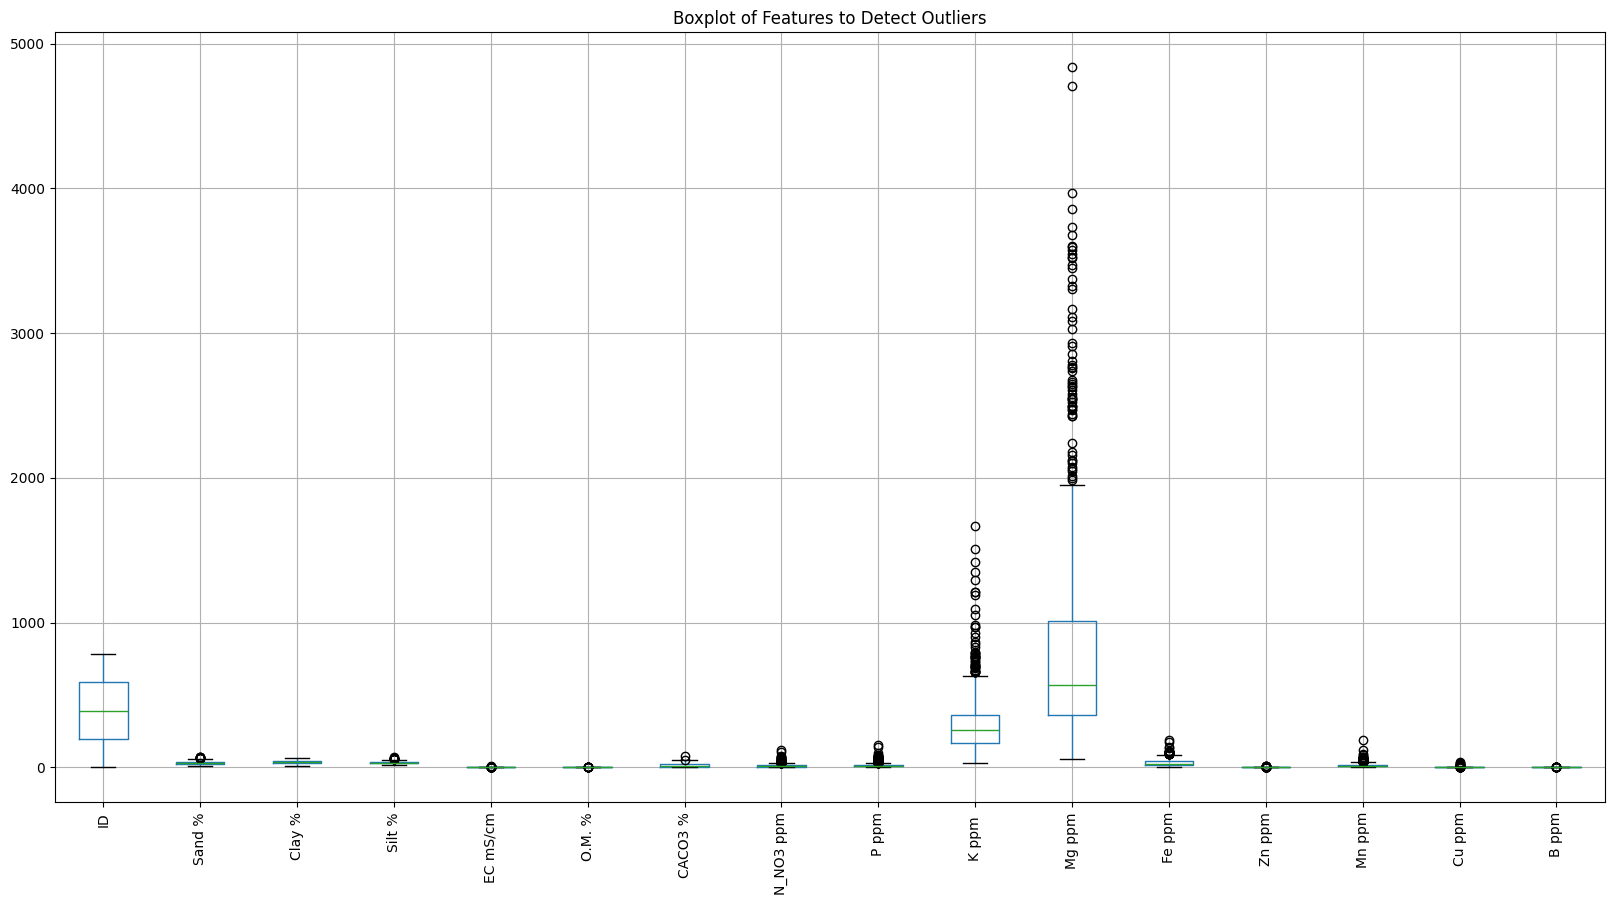

In [10]:
# Create boxplots for each feature
plt.figure(figsize=(20, 10))
df.drop('pH', axis=1).boxplot()
plt.xticks(rotation=90)
plt.title('Boxplot of Features to Detect Outliers')
plt.show()

The Z-score method is used to find how far away a data point is from the mean. Any value with a Z-score greater than 3 or less than -3 is considered an outlier.

In [11]:
# Calculate Z-Scores for the numerical columns
z_scores = np.abs(stats.zscore(df.select_dtypes(include=['float64', 'int64'])))

# Set threshold for outliers
threshold = 3

# Find indices where Z-score is greater than threshold
outliers = np.where(z_scores > threshold)

# Print outliers
print("Outliers found at indices:", outliers)


Outliers found at indices: (array([  1,   2,   5,  40,  40,  40,  40,  50,  51,  52,  53,  63,  64,
       106, 110, 114, 118, 123, 124, 133, 133, 150, 151, 153, 157, 157,
       163, 168, 176, 176, 176, 179, 180, 181, 182, 183, 184, 185, 187,
       191, 192, 199, 204, 238, 244, 244, 244, 247, 253, 257, 260, 266,
       266, 266, 270, 270, 274, 274, 276, 281, 282, 282, 282, 282, 282,
       283, 288, 289, 290, 303, 304, 304, 309, 311, 315, 315, 315, 315,
       317, 318, 319, 320, 322, 322, 333, 333, 333, 341, 343, 343, 347,
       347, 347, 353, 372, 372, 372, 372, 372, 373, 373, 373, 373, 454,
       455, 455, 466, 485, 499, 509, 511, 512, 515, 527, 538, 590, 595,
       596, 597, 597, 597, 597, 607, 608, 610, 621, 651, 659, 664, 665,
       668, 670, 679, 683, 689, 691, 692, 699, 706, 706, 706, 710, 710,
       720, 728, 739, 740, 741, 741, 742, 751, 752, 758, 758, 760, 761,
       761, 761, 761, 762, 764, 764, 766]), array([13, 13, 11,  6,  9, 10, 13, 12, 12, 14, 14, 16, 16, 15, 1

This method looks for outliers based on the spread of the middle 50% of the data.

Number of outliers per feature:
ID            0
Sand %       12
Clay %        0
Silt %       17
pH           23
EC mS/cm     51
O.M. %       16
CACO3 %       2
N_NO3 ppm    37
P ppm        60
K ppm        45
Mg ppm       61
Fe ppm       34
Zn ppm       59
Mn ppm       65
Cu ppm       64
B ppm        22
dtype: int64


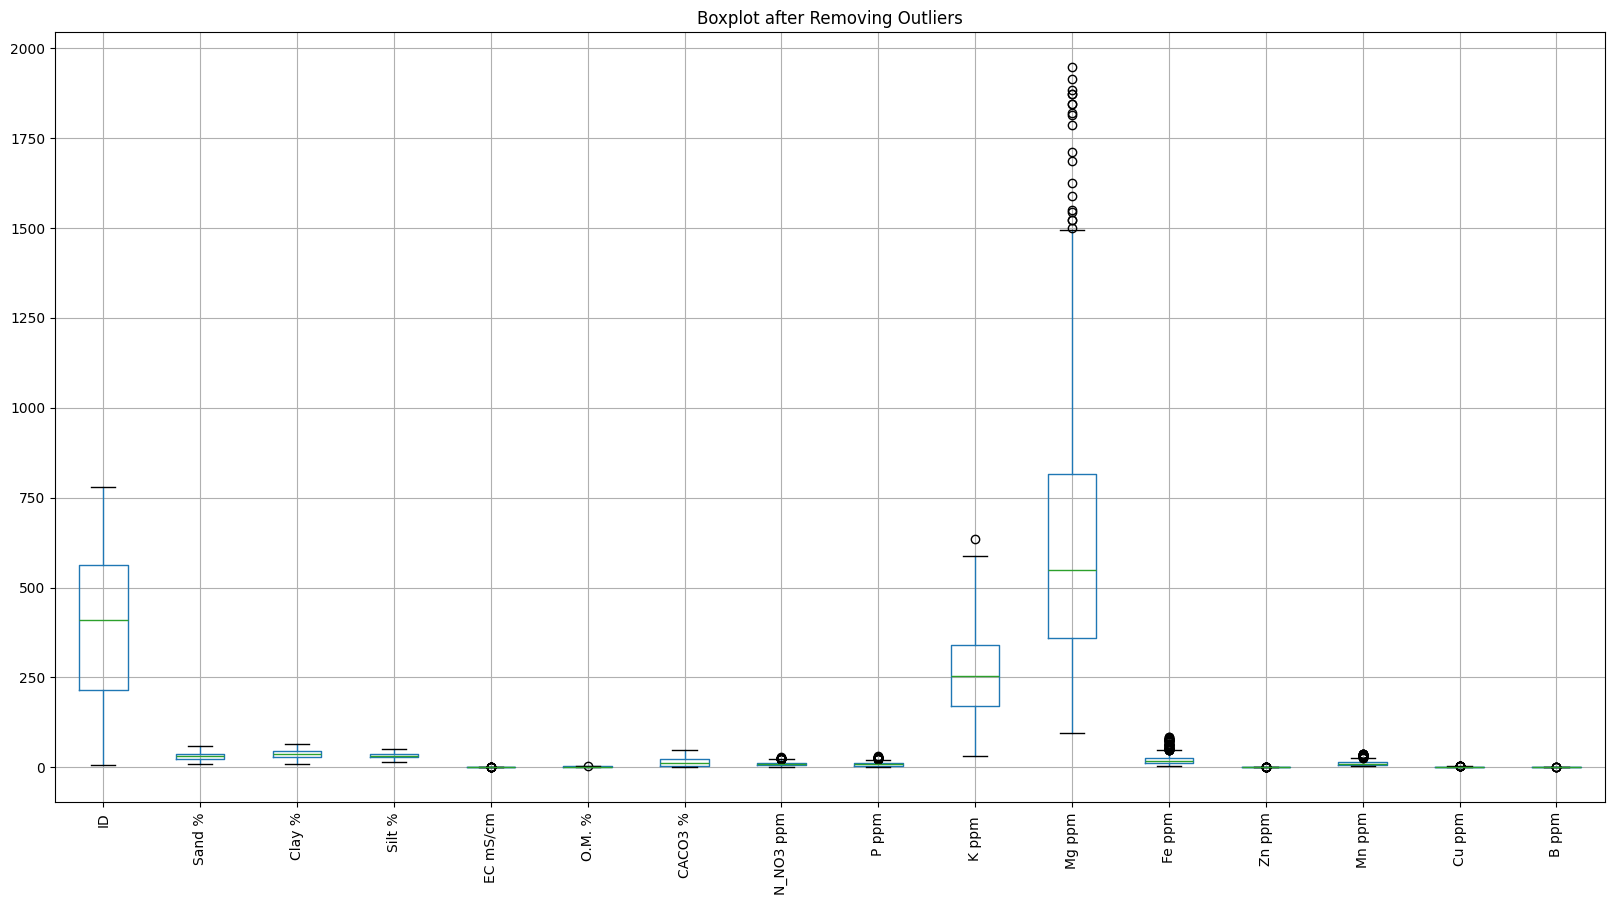

In [12]:
# Calculate IQR for each feature
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

# Visualize outliers
outliers_sum = outliers.sum()
print("Number of outliers per feature:")
print(outliers_sum)

# Optional: Filter dataset to remove outliers
df_cleaned = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Visualize the cleaned data
plt.figure(figsize=(20, 10))
df_cleaned.drop('pH', axis=1).boxplot()
plt.xticks(rotation=90)
plt.title('Boxplot after Removing Outliers')
plt.show()


also use scatter plots to detect outliers by plotting feature pairs.

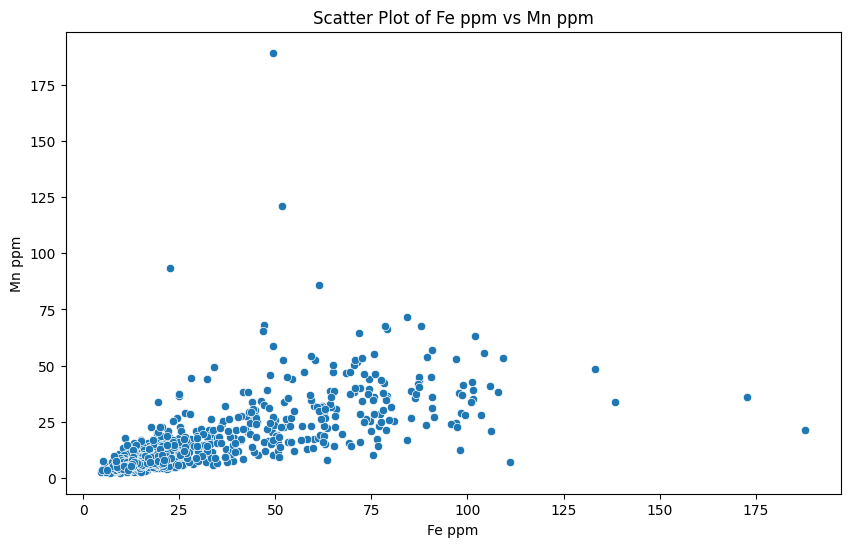

In [13]:
# Scatter plot of two features
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Fe ppm', y='Mn ppm')
plt.title('Scatter Plot of Fe ppm vs Mn ppm')
plt.show()


Original Shape: (781, 17): This means the dataset initially had 781 rows (samples) and 17 columns (features).

Shape After Removing Outliers: (452, 17): After removing outliers, the dataset now has 452 rows (samples) while keeping the same number of 17 features.

In [14]:
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1

    # Filtering out the outliers
    df_out = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

    return df_out

# Apply the function to remove outliers from the dataset
df_cleaned = remove_outliers_iqr(df)

# Check the shape of the dataset before and after outlier removal
print(f"Original shape: {df.shape}")
print(f"Shape after removing outliers: {df_cleaned.shape}")


Original shape: (781, 17)
Shape after removing outliers: (452, 17)


**Interpretation of Results:**
Original Shape: (781, 17) shows the dataset had 781 rows and 17 columns before removing outliers.

**Shape After Removing Outliers: ** (665, 17) means 116 rows (781 - 665 = 116) were considered outliers and removed based on the Z-score threshold.

**Why Use Z-Scores for Outlier Detection?**

Z-scores help standardize the data and measure how far a data point is from the mean.

Typically, a Z-score greater than 3 (or less than -3) suggests that a point is far from the average, which is why those points are often removed to avoid skewing the model.

**Difference Compared to IQR Method:**
Earlier, using the IQR method, a larger number of outliers (329 rows) were removed, while using the Z-score method here only removed 116 rows. This difference can arise because:

Z-scores are based on standard deviations and assume a normal distribution of the data.
IQR (Interquartile Range) method is more robust to skewed data and extreme values.

In [15]:
# Calculate Z-Scores for the numerical columns
z_scores = np.abs(stats.zscore(df.select_dtypes(include=['float64', 'int64'])))

# Remove rows with Z-Scores above 3 in any feature
df_cleaned_z = df[(z_scores < 3).all(axis=1)]

# Check the shape of the dataset before and after outlier removal
print(f"Original shape: {df.shape}")
print(f"Shape after removing outliers: {df_cleaned_z.shape}")


Original shape: (781, 17)
Shape after removing outliers: (665, 17)


This prepares and evaluates the model for predicting pH.

In [16]:
# Define features (X) and target (y)
X = df_cleaned.drop('pH', axis=1)  # Replace 'pH' with your target variable
y = df_cleaned['pH']

# Split the cleaned data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now, train your model (example using Decision Tree)
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)


# Preprocessing the Data

In [17]:
# Handle missing values (drop rows with missing data)
df.dropna(inplace=True)


In [18]:
# Split the dataset into features (X) and the target variable (y)
X = df.drop(columns=['pH'])  # Features (everything except pH)
y = df['pH']  # Target (pH)

In [19]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
# Standardize the features (scale them to have mean=0 and variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feature Selection

In [21]:
# Train a basic Random Forest model to check feature importance
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)


RandomForestRegressor(random_state=42)

In this case, "Fe ppm" has the highest importance (0.6875), meaning it plays the most significant role in the model's predictions. Variables like "CACO3 %" (0.1004) and "EC mS/cm" (0.0498) are also important. Features with lower values, such as "Sand %" (0.0035) and "Silt %" (0.0039)


Fe ppm is clearly the most influential feature in predicting pH. Features with very low importance scores, such as Sand % and Silt %, might be candidates for exclusion in future analyses or model training, depending on the context and goals.

In [22]:
# Get feature importance
importances = rf.feature_importances_
features = X.columns

# Display feature importance
for feature, importance in zip(features, importances):
    print(f'{feature}: {importance}')

# Optional: You can drop less important features based on this importance score.

ID: 0.034455551424397955
Sand %: 0.003466116093623511
Clay %: 0.0071732298090302375
Silt %: 0.0038580993826579702
EC mS/cm: 0.04976037170926961
O.M. %: 0.004969032741211688
CACO3 %: 0.10037812921398796
N_NO3 ppm: 0.015006525480288302
P ppm: 0.005203248260392524
K ppm : 0.009156276384893476
Mg ppm: 0.011167138942221114
Fe ppm: 0.6875053652490258
Zn ppm: 0.00604332500262423
Mn ppm: 0.041736754080361545
Cu ppm: 0.0051682126587675545
B ppm: 0.014952623567246503


# Train the Random Forest model and perform hyperparameter tuning

In [23]:
# Define the model
rf = RandomForestRegressor(random_state=42)

# Define a hyperparameter grid to search over
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}


In [24]:
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train)

# Best model from grid search
best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 100}


we will evaluate the model on the test data using metrics like RMSE and R² score.

In [25]:
# Make predictions on the test set
y_pred = best_rf.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse}')
print(f'R²: {r2}')


RMSE: 0.2610555252258711
R²: 0.9253068062368222


# Feature Importance Analysis

After training, we can analyze the feature importance scores to see which variables contributed the most to predicting soil pH.  (Fe ppm)

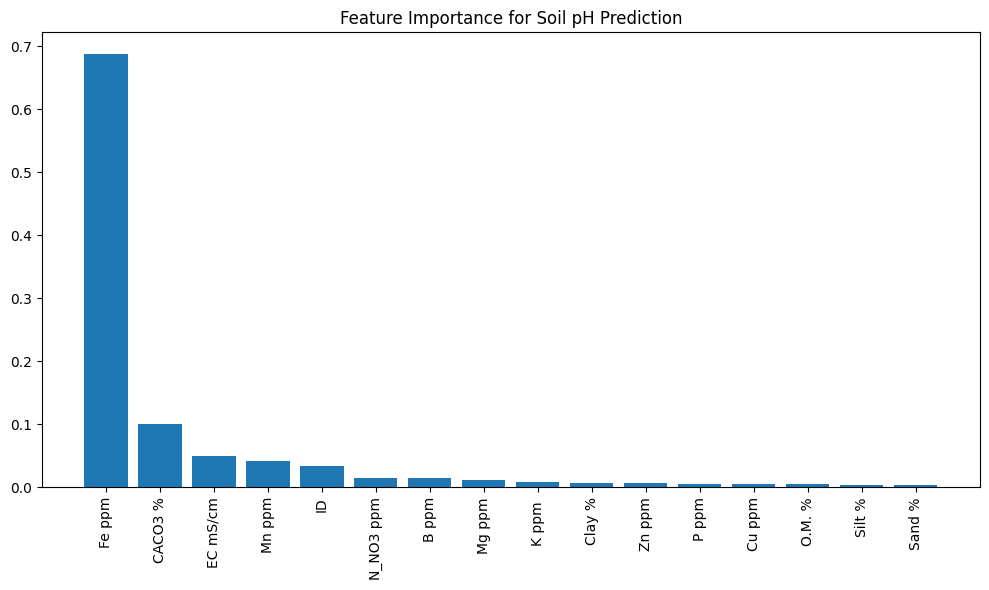

In [26]:
# Plot the feature importance
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Soil pH Prediction")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


# Train XGBoost Model

In [27]:
# Define the model
xgb = XGBRegressor(random_state=42)

# Define a hyperparameter grid to search over
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Perform grid search with cross-validation
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search_xgb.fit(X_train_scaled, y_train)

# Best model
best_xgb = grid_search_xgb.best_estimator_
print(f"Best XGBoost parameters: {grid_search_xgb.best_params_}")

# Evaluate the XGBoost model
y_pred_xgb = best_xgb.predict(X_test_scaled)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = mse_xgb ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'XGBoost RMSE: {rmse_xgb}')
print(f'XGBoost R²: {r2_xgb}')


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best XGBoost parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
XGBoost RMSE: 0.2598980688025789
XGBoost R²: 0.9259676806512283


# Stacking Models

In [28]:
# Define base models
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, random_state=42))
]

# Define the stacking model (meta-model is Linear Regression here)
stacked_model = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())

# Train the stacking model
stacked_model.fit(X_train_scaled, y_train)

# Evaluate the stacking model
y_pred_stack = stacked_model.predict(X_test_scaled)
mse_stack = mean_squared_error(y_test, y_pred_stack)
rmse_stack = mse_stack ** 0.5
r2_stack = r2_score(y_test, y_pred_stack)

print(f'Stacking RMSE: {rmse_stack}')
print(f'Stacking R²: {r2_stack}')


Stacking RMSE: 0.24792658088777644
Stacking R²: 0.9326307933621212



# Feature Engineering

In [29]:
# Create polynomial features (degree=2 for example)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train a model using polynomial features
rf_poly = RandomForestRegressor(n_estimators=100, random_state=42)
rf_poly.fit(X_train_poly, y_train)

# Evaluate the model
y_pred_poly = rf_poly.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = mse_poly ** 0.5
r2_poly = r2_score(y_test, y_pred_poly)

print(f'Polynomial Features RMSE: {rmse_poly}')
print(f'Polynomial Features R²: {r2_poly}')


Polynomial Features RMSE: 0.29124433970716906
Polynomial Features R²: 0.9070326957557108


# Feature Selection

use Recursive Feature Elimination (RFE) or model-based feature importance (e.g., from Random Forest or XGBoost).Instead of use all features, select only the most important ones to improve performance.

In [30]:
# Use RFE with a basic model (e.g., Linear Regression)
model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=5)  # Select top 5 features
rfe.fit(X_train_scaled, y_train)

# Get the selected features
selected_features = X.columns[rfe.support_]
print(f"Selected features: {selected_features}")

# Train a new model on the selected features
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)
rf_rfe = RandomForestRegressor(n_estimators=100, random_state=42)
rf_rfe.fit(X_train_rfe, y_train)

# Evaluate the model
y_pred_rfe = rf_rfe.predict(X_test_rfe)
mse_rfe = mean_squared_error(y_test, y_pred_rfe)
rmse_rfe = mse_rfe ** 0.5
r2_rfe = r2_score(y_test, y_pred_rfe)

print(f'RFE RMSE: {rmse_rfe}')
print(f'RFE R²: {r2_rfe}')


Selected features: Index(['ID', 'O.M. %', 'CACO3 %', 'Fe ppm', 'Mn ppm'], dtype='object')
RFE RMSE: 0.27546895398724686
RFE R²: 0.9168311741144698


# Hyperparameter Optimization with RandomizedSearchCV
Instead of GridSearchCV, use RandomizedSearchCV to explore a wider range of hyperparameters more efficiently.

In [ ]:
# Define the hyperparameter space for Random Forest
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Randomized Search
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=100, cv=5, random_state=42, n_jobs=-1)
random_search.fit(X_train_scaled, y_train)

# Best model from RandomizedSearchCV
best_rf_random = random_search.best_estimator_

# Evaluate the model
y_pred_random = best_rf_random.predict(X_test_scaled)
mse_random = mean_squared_error(y_test, y_pred_random)
rmse_random = mse_random ** 0.5
r2_random = r2_score(y_test, y_pred_random)

print(f'RandomizedSearchCV RMSE: {rmse_random}')
print(f'RandomizedSearchCV R²: {r2_random}')


# Train XGBoost Model

In [ ]:
!pip install xgboost
# Define the model
xgb = XGBRegressor(random_state=42)

# Train the model
xgb.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_xgb = xgb.predict(X_test_scaled)

# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = mse_xgb ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'XGBoost RMSE: {rmse_xgb}')
print(f'XGBoost R²: {r2_xgb}')


# Hyperparameter Tuning with GridSearchCV

In [ ]:
# Define the model
xgb = XGBRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Perform grid search with cross-validation
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search_xgb.fit(X_train_scaled, y_train)

# Best model from GridSearchCV
best_xgb = grid_search_xgb.best_estimator_
print(f"Best XGBoost parameters: {grid_search_xgb.best_params_}")

# Evaluate the model on the test set
y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = mse_xgb_tuned ** 0.5
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print(f'Tuned XGBoost RMSE: {rmse_xgb_tuned}')
print(f'Tuned XGBoost R²: {r2_xgb_tuned}')


# Advanced Hyperparameter Tuning with RandomizedSearchCV

In [ ]:
# Define the hyperparameter space
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.001, 0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [1, 1.5, 2],
    'reg_alpha': [0, 0.1, 0.2]
}

# Randomized search
random_search_xgb = RandomizedSearchCV(estimator=xgb, param_distributions=param_distributions,
                                       n_iter=100, cv=5, random_state=42, n_jobs=-1, verbose=2)
random_search_xgb.fit(X_train_scaled, y_train)

# Best model from RandomizedSearchCV
best_xgb_random = random_search_xgb.best_estimator_

# Evaluate the model on the test set
y_pred_xgb_random = best_xgb_random.predict(X_test_scaled)
mse_xgb_random = mean_squared_error(y_test, y_pred_xgb_random)
rmse_xgb_random = mse_xgb_random ** 0.5
r2_xgb_random = r2_score(y_test, y_pred_xgb_random)

print(f'RandomizedSearchCV XGBoost RMSE: {rmse_xgb_random}')
print(f'RandomizedSearchCV XGBoost R²: {r2_xgb_random}')


# Cross-Validation

In [ ]:
# Perform cross-validation on the best XGBoost model
cv_scores = cross_val_score(best_xgb_random, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = (-cv_scores) ** 0.5  # Convert negative MSE to RMSE

print(f'Cross-Validation RMSE: {cv_rmse_scores.mean()} ± {cv_rmse_scores.std()}')


Explanation

We trained and optimized an XGBoost model for predicting soil pH.

We tuned hyperparameters using GridSearchCV and RandomizedSearchCV to improve performance.

Model interpretation with SHAP helped us understand the contribution of each feature to the prediction.

Cross-validation confirmed the robustness of the model.

# Correlation Matrix Heatmap

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

# Set the title
plt.title('Correlation Heatmap of Features', size=15)

# Display the heatmap
plt.show()


# Feature-Target Correlation Heatmap

This bar plot shows how strongly each feature correlates with the target variable (soil pH). Features with high positive or negative correlations are the most influential in predicting soil pH.

In [ ]:
# Get the correlation of each feature with soil pH
target_correlation = correlation_matrix['pH'].sort_values(ascending=False)

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a bar plot of the correlations
sns.barplot(x=target_correlation.values, y=target_correlation.index, palette='coolwarm')

# Set the title and labels
plt.title('Correlation of Features with Soil pH', size=15)
plt.xlabel('Correlation Coefficient')

# Display the bar plot
plt.show()


# Heatmap for Highly Correlated Features

In [ ]:
# Set a threshold for high correlation (e.g., |correlation| > 0.7)
high_correlation = correlation_matrix[(correlation_matrix >= 0.7) | (correlation_matrix <= -0.7)]

# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap for highly correlated features
sns.heatmap(high_correlation, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

# Set the title
plt.title('Heatmap of Highly Correlated Features', size=15)

# Display the heatmap
plt.show()


# Decision Tree Model

We can apply the Decision Tree algorithm for predicting soil pH. Decision Trees are interpretable machine learning models that can handle both numerical and categorical data, and they don't require feature scaling.

In [ ]:
# Split data into training and test sets (if not done already)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree model
dt_regressor = DecisionTreeRegressor(random_state=42)

# Train the model
dt_regressor.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_regressor.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt ** 0.5
r2_dt = r2_score(y_test, y_pred_dt)

print(f'Decision Tree RMSE: {rmse_dt}')
print(f'Decision Tree R²: {r2_dt}')


Hyperparameter Tuning

In [ ]:
# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Initialize GridSearchCV with the Decision Tree
grid_search_dt = GridSearchCV(estimator=DecisionTreeRegressor(random_state=42), param_grid=param_grid,
                              cv=5, n_jobs=-1, verbose=2)

# Train with grid search
grid_search_dt.fit(X_train, y_train)

# Get the best estimator and its performance
best_dt = grid_search_dt.best_estimator_
print(f'Best Decision Tree parameters: {grid_search_dt.best_params_}')

# Predict on the test set using the best model
y_pred_dt_tuned = best_dt.predict(X_test)

# Evaluate the tuned model
mse_dt_tuned = mean_squared_error(y_test, y_pred_dt_tuned)
rmse_dt_tuned = mse_dt_tuned ** 0.5
r2_dt_tuned = r2_score(y_test, y_pred_dt_tuned)

print(f'Tuned Decision Tree RMSE: {rmse_dt_tuned}')
print(f'Tuned Decision Tree R²: {r2_dt_tuned}')


Visualize the Decision Tree

In [ ]:
# Set figure size
plt.figure(figsize=(20, 10))

# Plot the decision tree
plot_tree(best_dt, feature_names=X.columns, filled=True, rounded=True)

# Display the tree plot
plt.show()


Feature Importance

In [ ]:
# Get feature importance scores
importances = best_dt.feature_importances_

# Create a DataFrame for easy visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance in Decision Tree')
plt.show()


# Model Interpretation with SHAP

In [ ]:
!pip install shap
import shap

In [ ]:
# Train the best XGBoost model on the full dataset
best_xgb.fit(X_train_scaled, y_train)

# Create SHAP values
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Plot SHAP summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)



# Apply LIME to the Decision Tree

We can use LIME (Local Interpretable Model-agnostic Explanations) to explain individual predictions of our Decision Tree model. LIME provides local explanations by creating an interpretable model around each prediction, which helps you understand why a model made a particular prediction.

In [ ]:
!pip install lime
import lime
import lime.lime_tabular

In [ ]:
# Initialize the LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['pH'],
    mode='regression'
)

# Choose an instance from the test set to explain
i = 1  # Index of the test instance you want to explain
instance = X_test.iloc[i].values.reshape(1, -1)

# Generate explanation for the chosen instance
exp = explainer.explain_instance(
    data_row=instance[0],
    predict_fn=best_dt.predict
)

# Display the explanation
exp.show_in_notebook(show_table=True)

In [ ]:
# Plot the LIME explanation
exp.as_pyplot_figure()
plt.show()

In [ ]:
# Loop through the first 5 test instances and explain each one
for i in range(5):
    instance = X_test.iloc[i].values.reshape(1, -1)
    exp = explainer.explain_instance(
        data_row=instance[0],
        predict_fn=best_dt.predict
    )
    print(f"Explanation for instance {i}:")
    exp.show_in_notebook(show_table=True)


#Extra Work
Exploratory Data Analysis (EDA)

🔘 Explore the relationships between soil properties and the target variable (e.g., correlation analysis).

🔘 Numerical Feature Distributions

🔘 Analysing Features with histogram and QQ Plots(Quantile Quantile)

In [ ]:
# Visualize data distributions
plt.figure(figsize=(12, 6))

# Assuming your dataset is loaded into a pandas DataFrame named 'df'
sns.histplot(df['pH'], kde=True)

plt.title('Distribution of pH')
plt.xlabel('pH Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
num_cols = ['Sand %', 'Clay %', 'Silt %', 'pH', 'EC mS/cm', 'O.M. %', 'CACO3 %',
       'N_NO3 ppm', 'P ppm', 'K ppm ', 'Mg ppm', 'Fe ppm', 'Zn ppm', 'Mn ppm',
       'Cu ppm', 'B ppm']

In [ ]:
import math
features = num_cols
n_bins = 50
histplot_hyperparams = {
    'kde':True,
    'alpha':0.4,
    'stat':'percent',
    'bins':n_bins
}

columns = features
n_cols = 4
n_rows = math.ceil(len(columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
ax = ax.flatten()

for i, column in enumerate(columns):
    plot_axes = [ax[i]]
    # Assuming your data is in a pandas DataFrame called df, replace df with your DataFrame name
    sns.kdeplot(
        df[column],
        ax=ax[i], color='#9E3F00'
    )
     # titles
    ax[i].set_title(f'{column} Distribution');
    ax[i].set_xlabel(None)

    # remove axes to show only one at the end
    plot_axes = [ax[i]]
    handles = []
    labels = []
    for plot_ax in plot_axes:
        handles += plot_ax.get_legend_handles_labels()[0]
        labels += plot_ax.get_legend_handles_labels()[1]
        plot_ax.legend().remove()

for i in range(i+1, len(ax)):
    ax[i].axis('off')

fig.suptitle(f'Numerical Feature Distributions\n\n\n', ha='center',  fontweight='bold', fontsize=25)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), fontsize=25, ncol=3)
plt.tight_layout()

In [ ]:
# Analysing Features with histogram and Quantile Quantile plots
plt.figure(figsize=(12, 18))

# Assuming your dataset is loaded into a pandas DataFrame named 'df'
column_names = df.columns  # Get the column names of data

for i in range(len(column_names) // 2):
    plt.subplot(len(column_names) // 2, 4, i * 4 + 1)  # First column of the pair

    col1 = df[column_names[i * 2]]  # Access the first column directly

    # Plot histogram with KDE
    sns.histplot(col1, kde=True)
    plt.title(f'Column {column_names[i * 2]} - Histogram')

    plt.subplot(len(column_names) // 2, 4, i * 4 + 2)  # Second column of the pair

    # Plot probability plot
    stats.probplot(col1, dist="norm", plot=plt)
    plt.title(f'Column {column_names[i * 2]} - Probability Plot')
    if i * 2 + 1 < len(column_names):  # Check if there's another column
        plt.subplot(len(column_names) // 2, 4, i * 4 + 3)  # Third column of the pair

        col2 = df[column_names[i * 2 + 1]]  # Access the second column directly

        # Plot histogram with KDE
        sns.histplot(col2, kde=True)
        plt.title(f'Column {column_names[i * 2 + 1]} - Histogram')

        plt.subplot(len(column_names) // 2, 4, i * 4 + 4)  # Fourth column of the pair

        # Plot probability plot
        stats.probplot(col2, dist="norm", plot=plt)
        plt.title(f'Column {column_names[i * 2 + 1]} - Probability Plot')

plt.tight_layout()
plt.show()

# Apply ANN

ANNs are powerful models for capturing non-linear relationships, which could be beneficial depending on the complexity of your data.

In [ ]:
!pip install scikit-learn
!pip install tensorflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
# Assuming you have your features in 'df' and target variable in 'y'
# Replace 'target_variable_column_name' with the actual name of your target variable column
X = df.drop('pH', axis=1)  # Dropping the target variable from the features
y = df['pH']  # The target variable (soil pH)


# Now you can use X and y in train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 3: Build the ANN model
model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))  # Hidden layer 1
model.add(Dense(32, activation='relu'))  # Hidden layer 2   increase layer 2-3-5 and activation sigmoid
model.add(Dense(1, activation='linear'))  # Output layer (regression problem)

# Step 4: Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 5: Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Step 6: Evaluate the model
y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R²: {r2}")


# SVR

SVR can handle regression tasks well, but its performance depends on data complexity and proper tuning.

use a Support Vector Machine (SVM) model on  soil pH dataset for regression. In this case, use SVR (Support Vector Regression), which is the regression variant of SVM.

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# Step 3: Train the SVR model
svr = SVR(kernel='rbf', C=100, epsilon=0.1)
svr.fit(X_train_scaled, y_train)

# Step 4: Predict and evaluate
y_pred = svr.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R²: {r2}")
